In [ ]:
%load_ext autoreload
%autoreload 2
from twop_pipeline.intan.IntanData import *
from twop_pipeline.twop.getSuite2POutput import *
from twop_pipeline.twop.TwoPSync import *

intan_path = '/mnt/Gianna_Mattessich/Arenski_Data/NGF_MMN/WT/WT7628/WT7628_day1'
s2p_path = intan_path

intan_data = IntanData(intan_path, twop_channel=2, camera_channel=3, pd_channel=5, treadmill_channel=6,
                        plot_intan=True, intan_plot_start_s=300, intan_plot_end_s=302,
                          save_plot=True, plot_save_filename= os.path.join(os.path.join(intan_path, 'channels_plot.png')))
s2p_out = Suite2POutput(s2p_path)

sync = TwoPSync(s2p_output=s2p_out, intan_data=intan_data, out_dir_name='synced')
sync.run()

frame_times_synced = np.load(os.path.join(intan_path, 'synced', 'frame_times_synced.npy'))
frame_times_synced

In [2]:
from twop_pipeline.intan.intan_io import *

export_signal_times(intan_data, out_dir='synced')
synced_folderpath = os.path.join(intan_path,'synced')
camera_times_raw = np.load(os.path.join(synced_folderpath, 'camera_times_raw.npy'))
camera_times_raw

Exporting signal times to /mnt/Gianna_Mattessich/Arenski_Data/NGF_MMN/WT/WT7628/WT7628_day1/synced


array([  31.2491 ,   31.28505,   31.32125, ..., 7683.62565, 7683.65895,
       7683.6923 ], shape=(229569,))

In [3]:
from twop_pipeline.twop.TwoPAnalyze import *

s2p_path = '/mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p10'
ex_s2p = Suite2POutput(s2p_path)
get_deltaF(s2p_out=ex_s2p)
get_deltaF(suite2p_path=s2p_path)

Found Suite2P Path /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p10/suite2p!
Found scope fps from Experiment.xml file: 29.16


/home/gianna/Desktop/PythonProjects/2P_pipeline_v1/src/twop_pipeline/twop/compute_twop.py:66: RuntimeWarning: invalid value encountered in divide
  deltaF = (rawF - baseline) / baseline


Found Suite2P Path /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p10/suite2p!
Found scope fps from Experiment.xml file: 29.16


array([[ 0.04053238,  0.73774948, -0.031458  , ...,  0.04680851,
         0.08510643, -0.12036474],
       [-0.01360544, -0.00680272,  0.00340136, ...,  0.01706485,
        -0.01365188, -0.0443686 ],
       [ 0.01613643,  0.01494818,  0.00291766, ...,  0.20153148,
        -0.02339162,  1.15130188],
       ...,
       [-0.01551904,  0.6686548 ,  0.40593759, ..., -0.00119169,
         0.01268914,  0.00426827],
       [-0.018454  , -0.00878753, -0.00374188, ..., -0.01336562,
        -0.00496982,  0.0059774 ],
       [ 0.0182698 ,  0.17953262,  0.01361334, ..., -0.01296462,
        -0.01586732,  0.00373234]], shape=(144, 36000))

In [4]:
from twop_pipeline.state.FacemapSync import *
from twop_pipeline.state.getFacemapOutput import FacemapOutput

facemap_path = intan_path
facemap_out = FacemapOutput(facemap_path)
facemap_sync = FacemapSync(facemap_output=facemap_out, intan_data= intan_data, out_dir_name='synced')
facemap_sync.run(save_motion_npy=True, movement_percentile=65, save_pupil_data= True)
motion_synced = np.load(os.path.join(facemap_path, 'synced', 'motion.npy'))

Found facemap file path /mnt/Gianna_Mattessich/Arenski_Data/NGF_MMN/WT/WT7628/WT7628_day1/WT7628_10_21_24_Lamp5GCamp_V1_MMN_face_2024-10-21-155230-0000_proc.npy
Estimated camera FPS ≈ 29.985
Facemap motion signal contains 229244 frames, camera captured 229569 frames.
Threshold for face motion: 9005.253619388872
motion_bool True ratio: 0.2922345787105402
Threshold for treadmill: 1.2555079794356652
Threshold for pupil: 2290.6784234189213
Saved state parquet at /mnt/Gianna_Mattessich/Arenski_Data/NGF_MMN/WT/WT7628/WT7628_day1/synced/facemap_data.parquet!
Saved manifest to /mnt/Gianna_Mattessich/Arenski_Data/NGF_MMN/WT/WT7628/WT7628_day1/synced/facemap_manifest.json


In [5]:
from twop_pipeline.utils.io import read_parquet

read_parquet(os.path.join(facemap_path, 'synced', 'facemap_data.parquet'))

,time,motion_bool,locomotion_bool,pupil_bool,motion,treadmill,pupil_area
0,31.24910,False,False,True,23765.108647,1.254825,2352.800960
1,31.28505,False,False,True,23481.521140,1.254753,2352.967889
2,31.32125,False,False,True,22929.588151,1.253095,2353.278961
3,31.35580,False,False,True,22139.070054,1.255373,2353.692813
4,31.38975,False,False,True,21152.590885,1.254287,2354.158383
...,...,...,...,...,...,...,...
229564,7683.55895,False,False,False,26030.354644,1.254160,2048.813287
229565,7683.59230,False,False,False,28776.452800,1.254227,2028.635212
229566,7683.62565,False,False,False,31106.169397,1.254046,2011.307293
229567,7683.65895,False,False,False,32802.144800,1.254448,1998.580542



Reading Intan Technologies RHD Data File, Version 1.5

Found 3 amplifier channels.
Found 0 auxiliary input channels.
Found 0 supply voltage channels.
Found 3 board ADC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.
Found 0 temperature sensors channels.



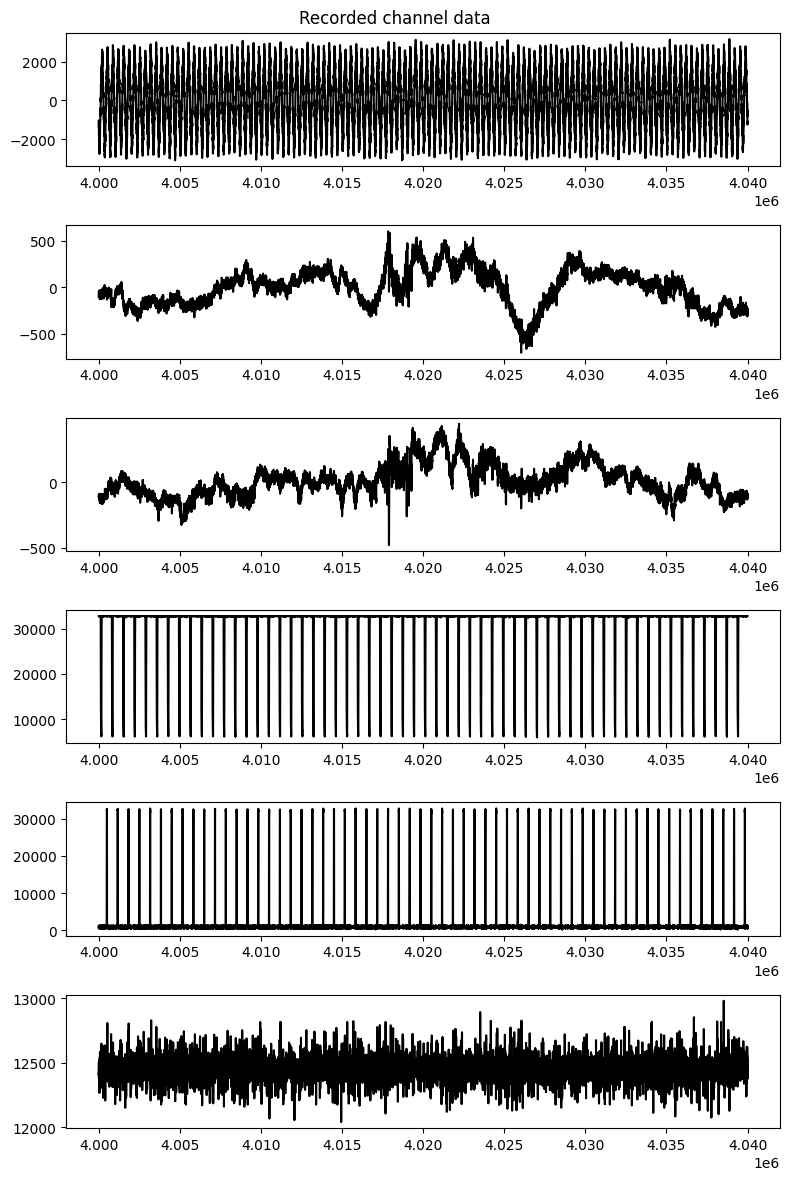

Getting transitions from 0:1291.10395 s
Found 36000 raw triggers for scope
Getting transitions from 0:1291.10395 s
Found 38476 raw triggers for camera


In [16]:
from twop_pipeline.lfp.readLFP import *

vip_basepath = '/mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p10'
lfp = load_lfp(f'{os.path.join(vip_basepath, os.path.basename(vip_basepath))}.lfp')
intan_data_vip = IntanData(intan_basepath=vip_basepath, twop_channel=3, camera_channel=4, plot_intan=True, intan_plot_start_s=200, intan_plot_end_s=202)

In [9]:

intan_sample_rate = 20e3  # Hz
fs_out = 1250               # Hz

downsample_factor = int(intan_sample_rate // fs_out)  # 16

num_samples_lfp = lfp.shape[1] if lfp.ndim > 1 else lfp.shape[0]

lfp_intan_indices = np.arange(num_samples_lfp) * downsample_factor
lfp_times = lfp_intan_indices / intan_sample_rate

In [21]:
extract_lfp(vip_basepath, amp_analog_aux_in=intan_data_vip.amp_analog_aux_in, intan_header=intan_data_vip.intan_header, channels=[1, 2])


Processing from disk in 13 batches...
LFP extraction complete. Saved to: /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p10/p10.lfp


array([[-56.       ,  62.587883 , 104.47503  , ..., -27.676863 ,
        -28.21639  , -62.722824 ],
       [110.       , 150.97502  , 172.33939  , ...,  31.10355  ,
          6.5616736, -26.372835 ]], shape=(2, 1613880), dtype=float32)